In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.logistic_regression import LogisticRegressionModel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

In [2]:
RANDOM_STATE = 42

features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (7352, 561) | X_test: (2947, 561)


In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [4]:
feature_subsets = ["Gyro", "Acc", "Body", "Gravity", "t", "f", "X", "Y", "Z", "XYZ-combined"]

feature_subsets_X_train = []
feature_subsets_X_test = []
for i,f in enumerate(feature_subsets):
    if(i < 4):
        indices = features.loc[features["feature_name"].str.contains(f), "index"].to_numpy() - 1
    elif(i < 6):
        indices = features.loc[features["feature_name"].str.startswith(f), "index"].to_numpy() - 1
    elif(i<9):
        regex = rf"-{f}(?:,\d)?"
        indices = features.loc[features["feature_name"].str.contains(regex), "index"].to_numpy() - 1
    else:
        regex = r"-[XYZ](?:,\d)?"
        indices = features.loc[~features["feature_name"].str.contains(regex), "index"].to_numpy() - 1

    feature_subsets_X_train.append(X_train_s[:,indices])
    feature_subsets_X_test.append(X_test_s[:,indices])


The following experiments are done to understand how different signal subsets affect the classification.

| Number | Experiment | Feature Subsets |
| ------ | ---------- | --------------- |
| 1 | Effect of sensor | only gyroscope, only accelerometer |
| 2 | Effect of component | only body, only gravity |
| 3 | Effect of domain | only time, only frequency |
| 4 | Effect of axis | only X, only Y, only Z, only multi-axis |

### Full Feature

Results using all the features to compare to.

In [5]:
# Full feature
learning_rate = 0.05
rows_full = []

model = LogisticRegressionModel(random_state=RANDOM_STATE)
model.fit(X_train_s, y_train_enc, learning_rate)
pred_full = model.predict(X_test_s)

rows_full.append(
            {
                "feature_subset": "full feature",
                "test_accuracy": accuracy_score(y_test_enc, pred_full),
                "test_macro_precision": precision_score(
                    y_test_enc, pred_full, average="macro", zero_division=0
                ),
                "test_macro_recall": recall_score(
                    y_test_enc, pred_full, average="macro", zero_division=0
                ),
                "test_macro_f1": f1_score(
                    y_test_enc, pred_full, average="macro", zero_division=0
                ),
            }
        )

,feature_subset,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,full feature,0.947404,0.950939,0.946722,0.94785


Experiment: full features
                    precision    recall  f1-score   support

           WALKING      0.941     0.992     0.966       496
  WALKING_UPSTAIRS      0.957     0.941     0.949       471
WALKING_DOWNSTAIRS      0.985     0.948     0.966       420
           SITTING      0.955     0.868     0.909       491
          STANDING      0.868     0.962     0.913       532
            LAYING      1.000     0.970     0.985       537

          accuracy                          0.947      2947
         macro avg      0.951     0.947     0.948      2947
      weighted avg      0.950     0.947     0.948      2947



<Figure size 640x480 with 0 Axes>

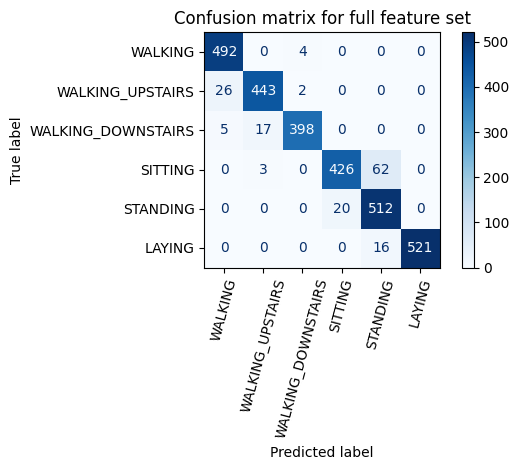

In [6]:
results = pd.DataFrame(rows_full)
display(results)

print(f"Experiment: full features")
print(classification_report(y_test_enc, pred_full, target_names=target_names, digits=3))

plt.figure()
c = confusion_matrix(y_test_enc, pred_full)
c_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=c, display_labels=activity_labels["activity_name"].to_list())
c_disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix for full feature set")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Experiment 1: Effect of Sensor

Compare accuracy when only using gyroscope feature subset and when only using accelerometer feature subset.

Gyroscope captures angular velocity and accelerometer captures linear acceleration.

In [7]:
# Experiment 1: effect of sensor
learning_rate = 0.05
experiments_1 = ["Gyroscope", "Accelerometer"]
pred_1 = []
rows_1 = []

for i,experiment in enumerate(experiments_1):
    model = LogisticRegressionModel(random_state=RANDOM_STATE)
    model.fit(feature_subsets_X_train[i], y_train_enc, learning_rate)
    pred_1.append(model.predict(feature_subsets_X_test[i]))
    
    rows_1.append(
                {
                    "feature_subset": experiment,
                    "test_accuracy": accuracy_score(y_test_enc, pred_1[i]),
                    "test_macro_precision": precision_score(
                        y_test_enc, pred_1[i], average="macro", zero_division=0
                    ),
                    "test_macro_recall": recall_score(
                        y_test_enc, pred_1[i], average="macro", zero_division=0
                    ),
                    "test_macro_f1": f1_score(
                        y_test_enc, pred_1[i], average="macro", zero_division=0
                    ),
                }
            )

#### Results

The accuracy scores for both feature subsets is shown below as well as classification reports and confusion matrices.

,feature_subset,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,Gyroscope,0.810655,0.813258,0.814157,0.813196
1,Accelerometer,0.897184,0.902849,0.896972,0.898628


Experiment: Gyroscope only
                    precision    recall  f1-score   support

           WALKING      0.891     0.843     0.866       496
  WALKING_UPSTAIRS      0.929     0.941     0.935       471
WALKING_DOWNSTAIRS      0.800     0.848     0.823       420
           SITTING      0.696     0.747     0.721       491
          STANDING      0.817     0.806     0.812       532
            LAYING      0.746     0.700     0.722       537

          accuracy                          0.811      2947
         macro avg      0.813     0.814     0.813      2947
      weighted avg      0.812     0.811     0.811      2947



<Figure size 640x480 with 0 Axes>

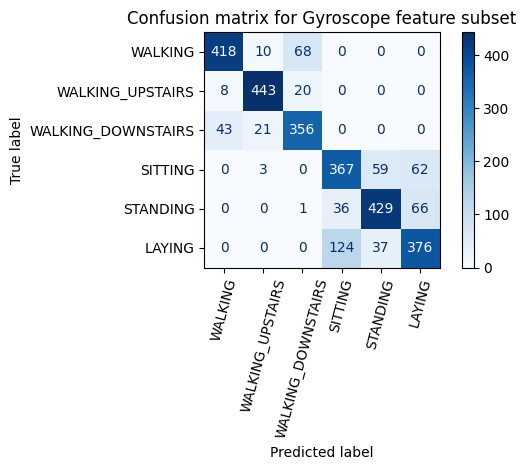

Experiment: Accelerometer only
                    precision    recall  f1-score   support

           WALKING      0.898     0.960     0.928       496
  WALKING_UPSTAIRS      0.910     0.898     0.904       471
WALKING_DOWNSTAIRS      0.982     0.921     0.951       420
           SITTING      0.853     0.766     0.807       491
          STANDING      0.778     0.878     0.825       532
            LAYING      0.996     0.959     0.977       537

          accuracy                          0.897      2947
         macro avg      0.903     0.897     0.899      2947
      weighted avg      0.901     0.897     0.898      2947



<Figure size 640x480 with 0 Axes>

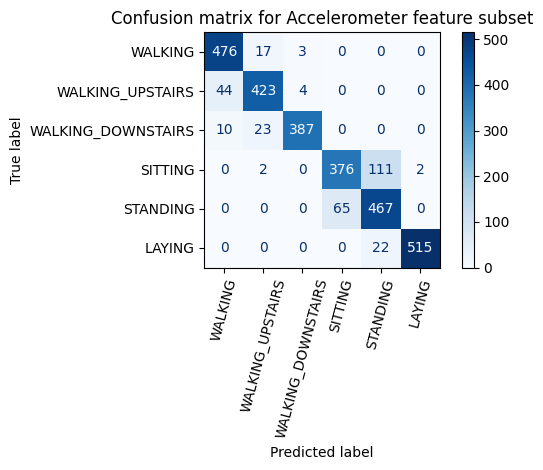

In [8]:
results = pd.DataFrame(rows_1)
display(results)

for i,experiment in enumerate(experiments_1):
    print(f"Experiment: {experiment} only")
    print(classification_report(y_test_enc, pred_1[i], target_names=target_names, digits=3))

    plt.figure()
    c = confusion_matrix(y_test_enc, pred_1[i])
    c_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=c, display_labels=activity_labels["activity_name"].to_list())
    c_disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion matrix for {experiment} feature subset")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

Using only the gyroscope feature susbet, there is confusion between walking, walking upstairs, and walking downstairs and there is confusion between sitting, standing, and laying. Since the gyroscope measures rotation, its data is not enough to distinguish between walking and walking upstairs or walking downstairs because the movements are quite similar. Sitting, standing, and laying involve very little angular movemement so the gyroscope data is enough to distinguish them from walking, but not to distinguish between the three classes.

Using only the accelerometer feature subset, there is confusion between walking, walking upstairs, and walking downstairs and there is confusion between sitting and standing. Walking and walking upstairs or walking downstairs are difficult to differentiate with the accelerometer on its own as well because the linear acceleration is similar. Laying is detected well because the accelerometer has gravitational information which tells which way the device is oriented. When laying down, the device is in a very different position from when standing or sitting. The accelerometer confuses sitting and standing because the orientation of the device is only slightly different between the two and can depend greatly on the subject's posture during the two activities. 

This shows that the combination of data from the gyroscope and accelerometer is necessary to distinguish between walking, walking upstairs, and walking downstairs since the differences from both sources are subtle but when combined, there is enough data to separate the classes. 

Between the two, the accelerometer on its own gives a higher test accuracy and f1 score (0.897 and 0.899) which is expected because it has information on both the linear acceleration and the orientation of the device. The gyroscope on its own gives less data to be able to separate the classes (0.811 and 0.813), but it does signficantly improve the accuracy when combined with the data from the accelerometer (0.947 and 0.948).

### Experiment 2: Effect of Component

Compare accuracy when only using body feature subset and when only using gravity feature subset.

All the data from the gyroscope is body acceleration data, but the data from the accelerometer is split into body acceleration and gravity data. The gravity data tells about the orientation of the device.

In [9]:
# Experiment 2: effect of component
learning_rate = 0.05
experiments_2 = ["Body", "Gravity"]
pred_2 = []
rows_2 = []

for i,experiment in enumerate(experiments_2):
    model = LogisticRegressionModel(random_state=RANDOM_STATE)
    model.fit(feature_subsets_X_train[i+2], y_train_enc, learning_rate)
    pred_2.append(model.predict(feature_subsets_X_test[i+2]))
    
    rows_2.append(
                {
                    "feature_subset": experiment,
                    "test_accuracy": accuracy_score(y_test_enc, pred_2[i]),
                    "test_macro_precision": precision_score(
                        y_test_enc, pred_2[i], average="macro", zero_division=0
                    ),
                    "test_macro_recall": recall_score(
                        y_test_enc, pred_2[i], average="macro", zero_division=0
                    ),
                    "test_macro_f1": f1_score(
                        y_test_enc, pred_2[i], average="macro", zero_division=0
                    ),
                }
            )

#### Results

The accuracy scores for both feature subsets is shown below as well as classification reports and confusion matrices.

,feature_subset,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,Body,0.915168,0.918820,0.916818,0.917186
1,Gravity,0.859857,0.870559,0.855952,0.858651


Experiment: Body only
                    precision    recall  f1-score   support

           WALKING      0.955     0.988     0.971       496
  WALKING_UPSTAIRS      0.950     0.962     0.956       471
WALKING_DOWNSTAIRS      0.990     0.940     0.965       420
           SITTING      0.831     0.833     0.832       491
          STANDING      0.864     0.930     0.896       532
            LAYING      0.923     0.847     0.883       537

          accuracy                          0.915      2947
         macro avg      0.919     0.917     0.917      2947
      weighted avg      0.916     0.915     0.915      2947



<Figure size 640x480 with 0 Axes>

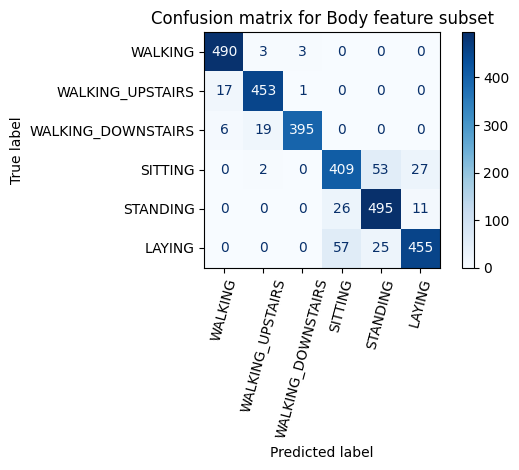

Experiment: Gravity only
                    precision    recall  f1-score   support

           WALKING      0.828     0.972     0.894       496
  WALKING_UPSTAIRS      0.856     0.868     0.862       471
WALKING_DOWNSTAIRS      0.970     0.764     0.855       420
           SITTING      0.830     0.717     0.769       491
          STANDING      0.740     0.865     0.797       532
            LAYING      1.000     0.950     0.974       537

          accuracy                          0.860      2947
         macro avg      0.871     0.856     0.859      2947
      weighted avg      0.868     0.860     0.860      2947



<Figure size 640x480 with 0 Axes>

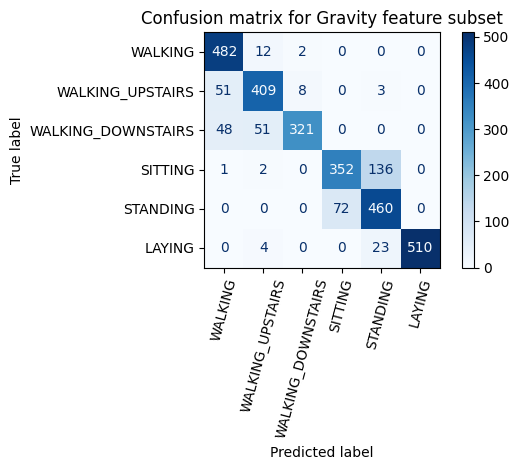

In [10]:
results = pd.DataFrame(rows_2)
display(results)

for i,experiment in enumerate(experiments_2):
    print(f"Experiment: {experiment} only")
    print(classification_report(y_test_enc, pred_2[i], target_names=target_names, digits=3))

    plt.figure()
    c = confusion_matrix(y_test_enc, pred_2[i])
    c_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=c, display_labels=activity_labels["activity_name"].to_list())
    c_disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion matrix for {experiment} feature subset")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

Using only the body acceleration data, the accuracy and f1 scores for walking, walking upstairs, and walking downstairs are very close to the baseline results using all the features. There is confusion between sitting, standing, and laying and this is expected because device orientation is a key differentiator between laying and sitting or standing. The subtle differences in device orientation also help to separate sitting and standing when paired with the subtle differences in the body acceleration when sitting and standing (swaying, adjustments, etc.). 

Using only the gravity data, there is confusion between walking, walking upstairs, and walking downstairs and there is confusion between sitting and standing. Although the gravity feature subset only includes the device orientation, during dynamic movements the orientation changes while during static movement it mostly stays the same. This is why even with only this data, the model can separate dynamic and static, but it has trouble differentiating the different walking directions because it does not have body acceleration information. The device orientation is enough to distinguish laying very well as expected, but not to distinguish sitting from standing. This is because while sitting and standing, the device orienation is not very different and depends more on the subject's posture rather than the activity itself. This shows that the subtle changes in body acceleration in addition to device orientation are what help separate sitting and standing.  

### Experiment 3: Effect of Domain

Compare accuracy when only using time feature subset and when only using frequency feature subset.

Time-domain data shows how the signals change over a window of time, while frequency-domain data describes the signals' frequency.

In [11]:
# Experiment 3: effect of domain
learning_rate = 0.05
experiments_3 = ["Time", "Frequency"]
pred_3 = []
rows_3 = []

for i,experiment in enumerate(experiments_3):
    model = LogisticRegressionModel(random_state=RANDOM_STATE)
    model.fit(feature_subsets_X_train[i+4], y_train_enc, learning_rate)
    pred_3.append(model.predict(feature_subsets_X_test[i+4]))
    
    rows_3.append(
                {
                    "feature_subset": experiment,
                    "test_accuracy": accuracy_score(y_test_enc, pred_3[i]),
                    "test_macro_precision": precision_score(
                        y_test_enc, pred_3[i], average="macro", zero_division=0
                    ),
                    "test_macro_recall": recall_score(
                        y_test_enc, pred_3[i], average="macro", zero_division=0
                    ),
                    "test_macro_f1": f1_score(
                        y_test_enc, pred_3[i], average="macro", zero_division=0
                    ),
                }
            )

#### Results

The accuracy scores for both feature subsets is shown below as well as classification reports and confusion matrices.

,feature_subset,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,Time,0.946047,0.948866,0.945510,0.946378
1,Frequency,0.874788,0.881153,0.875972,0.876778


Experiment: Time only
                    precision    recall  f1-score   support

           WALKING      0.926     0.988     0.956       496
  WALKING_UPSTAIRS      0.964     0.921     0.942       471
WALKING_DOWNSTAIRS      0.983     0.962     0.972       420
           SITTING      0.944     0.866     0.903       491
          STANDING      0.877     0.951     0.913       532
            LAYING      0.998     0.985     0.992       537

          accuracy                          0.946      2947
         macro avg      0.949     0.946     0.946      2947
      weighted avg      0.948     0.946     0.946      2947



<Figure size 640x480 with 0 Axes>

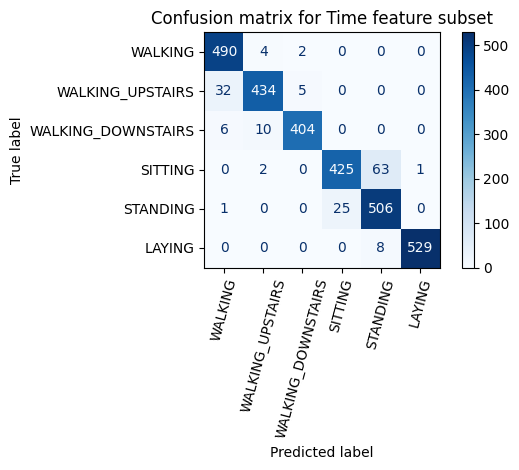

Experiment: Frequency only
                    precision    recall  f1-score   support

           WALKING      0.916     0.992     0.953       496
  WALKING_UPSTAIRS      0.929     0.919     0.924       471
WALKING_DOWNSTAIRS      0.984     0.905     0.943       420
           SITTING      0.797     0.711     0.751       491
          STANDING      0.777     0.897     0.832       532
            LAYING      0.883     0.832     0.857       537

          accuracy                          0.875      2947
         macro avg      0.881     0.876     0.877      2947
      weighted avg      0.877     0.875     0.874      2947



<Figure size 640x480 with 0 Axes>

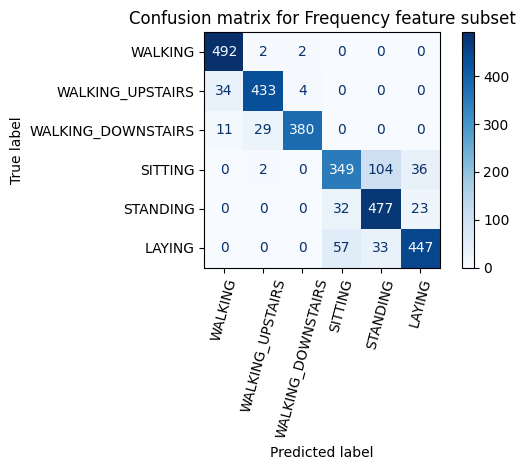

In [12]:
results = pd.DataFrame(rows_3)
display(results)

for i,experiment in enumerate(experiments_3):
    print(f"Experiment: {experiment} only")
    print(classification_report(y_test_enc, pred_3[i], target_names=target_names, digits=3))

    plt.figure()
    c = confusion_matrix(y_test_enc, pred_3[i])
    c_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=c, display_labels=activity_labels["activity_name"].to_list())
    c_disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion matrix for {experiment} feature subset")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

When only using the time feature subset, the test accuracy and f1 score are high and close to the baseline using all features. This shows that most of the classification can be done based on time-domain data only.

When only using the frequency feature subset, the test accuracy and f1 score are lower and there is more confusion between some classes. Walking is distinguished better in frequency-domain perhaps due to the frequency of movements being more even when walking on a flat surface vs when walking upstairs or downstairs. There is more confusion between sitting, standing, and laying. This is because the frequency-domain data does not include any gravity data from the accelerometer, so the device orientation is not included. As discussed above, the device orientation is crucial in distinguishing between the static activities, especially laying.

### Experiment 4: Effect of Axis

Compare accuracy when only using X,Y,Z feature subsets and when only using multi-axis feature subset.

X-axis is vertical (up and down), y-axis is horizontal (side to side), z-axis is forward (forward and back). The multi-axis feature subset only includes features that were derived using multiple axes (two or all three).

In [13]:
# Experiment 4: effect of axis
learning_rate = 0.05
experiments_4 = ["X-Axis", "Y-Axis", "Z-Axis", "Multi-Axis"]
pred_4 = []
rows_4 = []

for i,experiment in enumerate(experiments_4):
    model = LogisticRegressionModel(random_state=RANDOM_STATE)
    model.fit(feature_subsets_X_train[i+6], y_train_enc, learning_rate)
    pred_4.append(model.predict(feature_subsets_X_test[i+6]))
    
    rows_4.append(
                {
                    "feature_subset": experiment,
                    "test_accuracy": accuracy_score(y_test_enc, pred_4[i]),
                    "test_macro_precision": precision_score(
                        y_test_enc, pred_4[i], average="macro", zero_division=0
                    ),
                    "test_macro_recall": recall_score(
                        y_test_enc, pred_4[i], average="macro", zero_division=0
                    ),
                    "test_macro_f1": f1_score(
                        y_test_enc, pred_4[i], average="macro", zero_division=0
                    ),
                }
            )

#### Results

The accuracy scores for all four feature subsets is shown below as well as classification reports and confusion matrices.

,feature_subset,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,X-Axis,0.912453,0.913505,0.910772,0.911488
1,Y-Axis,0.821513,0.827688,0.817313,0.819528
2,Z-Axis,0.766203,0.779187,0.765793,0.766956
3,Multi-Axis,0.894469,0.903019,0.893343,0.895542


Experiment: X-Axis only
                    precision    recall  f1-score   support

           WALKING      0.887     0.962     0.923       496
  WALKING_UPSTAIRS      0.904     0.856     0.879       471
WALKING_DOWNSTAIRS      0.948     0.912     0.930       420
           SITTING      0.887     0.835     0.860       491
          STANDING      0.855     0.900     0.877       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.912      2947
         macro avg      0.914     0.911     0.911      2947
      weighted avg      0.913     0.912     0.912      2947



<Figure size 640x480 with 0 Axes>

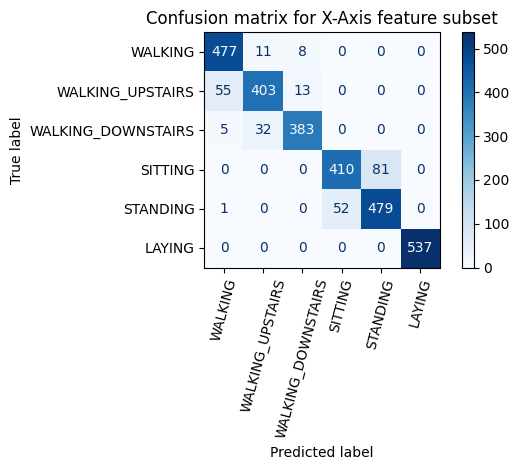

Experiment: Y-Axis only
                    precision    recall  f1-score   support

           WALKING      0.728     0.897     0.804       496
  WALKING_UPSTAIRS      0.912     0.815     0.861       471
WALKING_DOWNSTAIRS      0.840     0.714     0.772       420
           SITTING      0.767     0.739     0.753       491
          STANDING      0.793     0.842     0.817       532
            LAYING      0.925     0.896     0.910       537

          accuracy                          0.822      2947
         macro avg      0.828     0.817     0.820      2947
      weighted avg      0.828     0.822     0.822      2947



<Figure size 640x480 with 0 Axes>

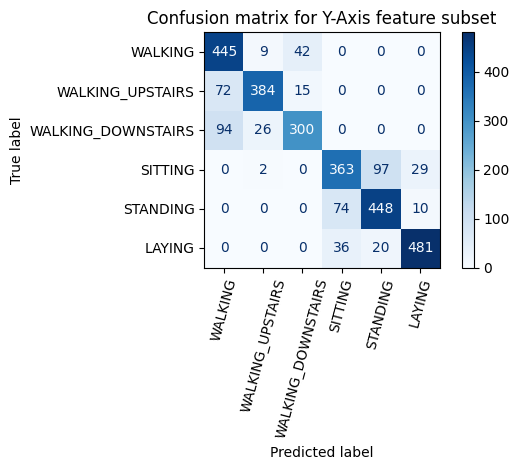

Experiment: Z-Axis only
                    precision    recall  f1-score   support

           WALKING      0.782     0.804     0.793       496
  WALKING_UPSTAIRS      0.852     0.904     0.877       471
WALKING_DOWNSTAIRS      0.805     0.726     0.763       420
           SITTING      0.593     0.597     0.595       491
          STANDING      0.681     0.859     0.760       532
            LAYING      0.962     0.704     0.813       537

          accuracy                          0.766      2947
         macro avg      0.779     0.766     0.767      2947
      weighted avg      0.780     0.766     0.767      2947



<Figure size 640x480 with 0 Axes>

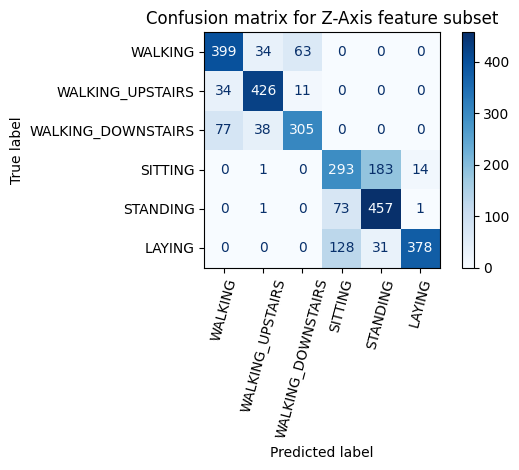

Experiment: Multi-Axis only
                    precision    recall  f1-score   support

           WALKING      0.893     0.988     0.938       496
  WALKING_UPSTAIRS      0.915     0.894     0.904       471
WALKING_DOWNSTAIRS      0.984     0.890     0.935       420
           SITTING      0.867     0.743     0.800       491
          STANDING      0.759     0.895     0.821       532
            LAYING      1.000     0.950     0.974       537

          accuracy                          0.894      2947
         macro avg      0.903     0.893     0.896      2947
      weighted avg      0.900     0.894     0.895      2947



<Figure size 640x480 with 0 Axes>

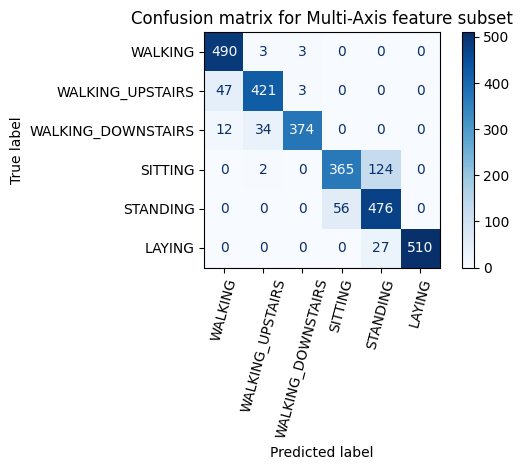

In [14]:
results = pd.DataFrame(rows_4)
display(results)

for i,experiment in enumerate(experiments_4):
    print(f"Experiment: {experiment} only")
    print(classification_report(y_test_enc, pred_4[i], target_names=target_names, digits=3))

    plt.figure()
    c = confusion_matrix(y_test_enc, pred_4[i])
    c_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=c, display_labels=activity_labels["activity_name"].to_list())
    c_disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion matrix for {experiment} feature subset")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

When only using the X-axis feature subset, the test accuracy and f1 score are still relatively high. This shows that a lot of the data needed to classify is along the X-axis. This makes sense as the X-axis is vertical so any movement up and down can be detected and gravity can be detected. Laying is separated well because when laying the X-axis is parallel with the ground so there will be very little gravity in the X-axis direction, which is a very different device orientation from the other classes. There is confusion between walking, walking upstairs and walking downstairs because information about how the body moves side to side and front and back is missing. This movement is necessary to tell whether the subject is walking upstairs or downstairs because the body moves differently between the two activities in the other two axes. For example, when walking upstairs, the body tends to lean forward (z-axis) or the extra exertion makes the body sway slightly from side to side (y-axis). There is confusion between sitting and standing for similar reasons. For example, when standing, the body might sway side to side slightly to keep balance (y-axis) or when sitting, the body might lean forward slightly (z-axis).

When only using the Y-axis feature subset, the test accuracy and f1 score are lower than when using X-axis feature subset. There is confusion between walking, walking upstairs, and walking downstairs for the same reasons as mentioned for the X-axis feature subset, however there is more confusion than with the X-axis indicating that the more defining information comes from the X-axis and not the Y-axis. There is confusion between sitting, standing, and laying because there is not much difference the Y-axis direction during these activities, especially between standing and sitting. Laying is somewhat differentiated by the gravity signal, but when sitting and standing, the Y-axis points horizontally and any small movement side to side can happen during either activity.

When only using the Z-axis feature subset, the test accuracy and f1 score are even lower. This shows that the Z-axis on its own contributes the least amount of information out of the three axes. There is confusion between walking, walking upstairs, and walking downstairs for the same reasons as described above for the other axes. There is confusion between sitting, standing, and laying because there is not much difference the Z-axis direction during these activities.

When only using the multi-axis feature subset, there is confusion between walking, walking upstairs, and walking downstairs, and there is confusion between sitting and standing. Although the test accuracy and f1 score are better than for Y-axis only and Z-axis only, they are less than for the X-axis only. This shows that the signals along the X-axis give the most information, even compared to combined features.